# Intensity averaging

09.11.2022 - Sören

## Initial setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma, iv

In [2]:
rng = np.random.default_rng()

## Photon detection with shot noise

Any photon emission process is of stochastic nature and exhibits shot noise. Shot noise is typically described by a Poisson distribution unless bunching or antibunching is introduced by the quantum systems.

In [3]:
intensity_mean = 2
n_samples = 10_000

In [4]:
intensities = rng.poisson(lam=intensity_mean, size=n_samples)

In [5]:
intensities.mean()

2.0016

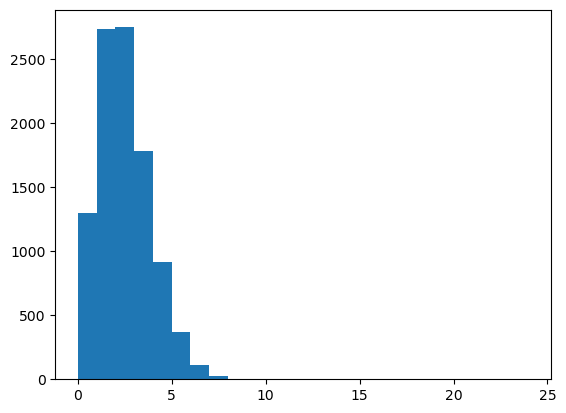

In [6]:
plt.hist(intensities, bins=range(0, 25, 1), log=False);

## Photon detection with EMCCD readout noise

If single photons are detected by an EMCCD camera introducing amplification by a high gain, additional gamma distributed noise is introduced.

The probability mass function amplification_noise(x, n_photons, gain) denotes the probability that `n_photons` input photo electrons (in one pixel) with
an electron multiplying gain of `gain` create `x` output electrons after the gain register.

References: 
* Speiser et al. https://doi.org/10.1038/s41592-021-01236-x
* Chao et al. https://doi.org/10.1117/12.2004621
* Mortensen et al. https://doi.org/10.1038/nmeth.1447

### Amplification noise from given detected photons

In the following we show that the equation by Speiser and Chao are identical.

#### following Speiser et al.

In [7]:
def amplification_noise_speiser(x: int, n_photons: int, gain: int) -> int:
    return 1 / (gamma(n_photons) * gain**n_photons) * np.float_power(x, (n_photons - 1)) * np.exp(-x / gain)

In [8]:
n_photons = 2
gain = 200

sum of amplification_noise: 0.9999979163073157


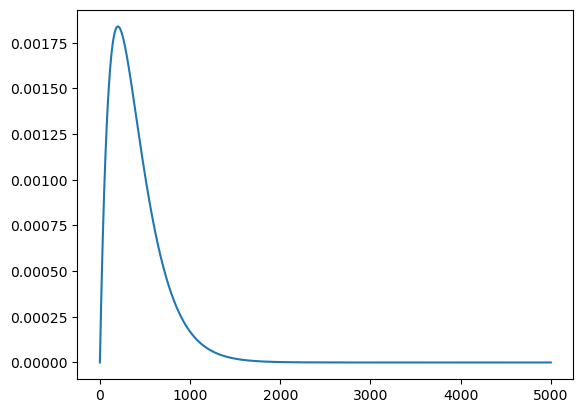

In [9]:
x = np.arange(5_000)
print("sum of amplification_noise:", np.sum(amplification_noise_speiser(x, n_photons=n_photons, gain=gain)))
plt.plot(x, amplification_noise_speiser(x, n_photons=n_photons, gain=gain));

#### following Chao et al.

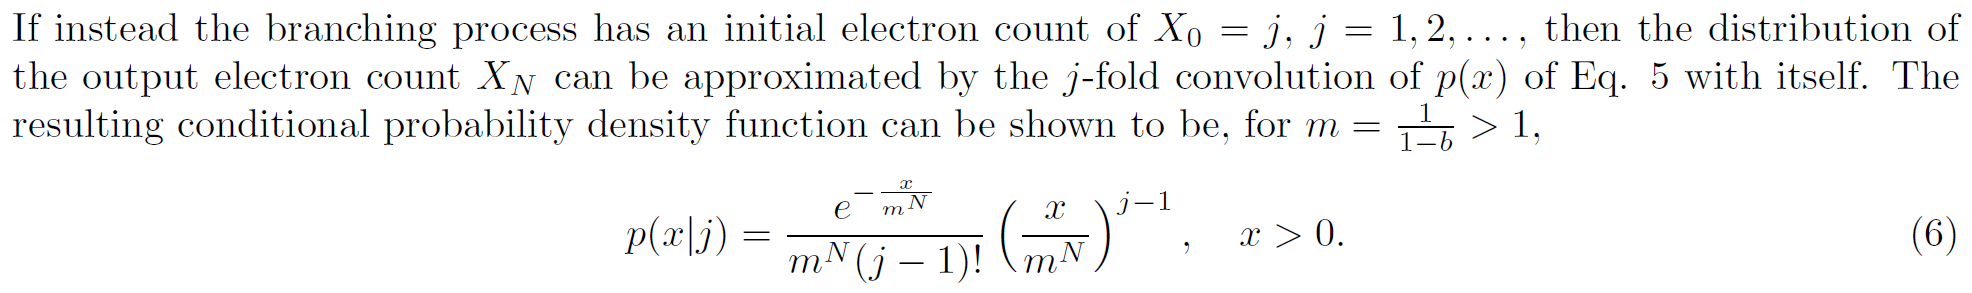

In [10]:
def amplification_noise_chao(x: int, n_photons: int, gain: int) -> int:
    return 1 / (gamma(n_photons) * gain) * np.float_power(x/gain, n_photons-1) * np.exp(-x / gain)

In [11]:
n_photons = 2
gain = 200

amplification_noise: 0.9999979163073157
amplification_noise: 0.9999979163073157


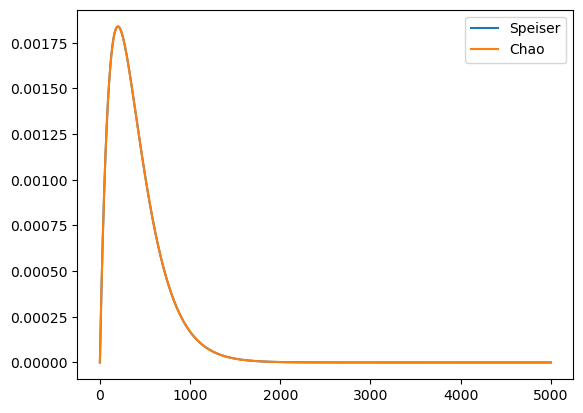

In [12]:
x = np.arange(5_000)
print("amplification_noise:", np.sum(amplification_noise_speiser(x, n_photons=n_photons, gain=gain)))
print("amplification_noise:", np.sum(amplification_noise_chao(x, n_photons=n_photons, gain=gain)))

plt.plot(x, amplification_noise_speiser(x, n_photons=n_photons, gain=gain), label="Speiser");
plt.plot(x, amplification_noise_chao(x, n_photons=n_photons, gain=gain), label="Chao");
plt.legend();

#### We stick to Chao's equation and proceed...

In [13]:
def amplification_noise(x: int, n_photons: int, gain: int) -> int:
    return 1 / (gamma(n_photons) * gain) * np.float_power(x/gain, n_photons-1) * np.exp(-x / gain)

In [14]:
n_photons = 1
gain = 200

sum of amplification_noise: 1.0025020833185425


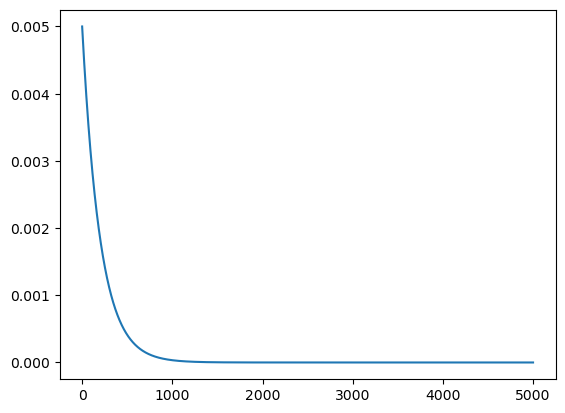

In [15]:
x = np.arange(5_000)
print("sum of amplification_noise:", np.sum(amplification_noise(x, n_photons=n_photons, gain=gain)))
plt.plot(x, amplification_noise(x, n_photons=n_photons, gain=gain));

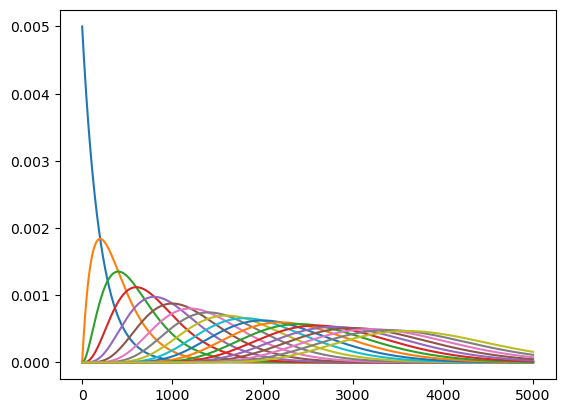

In [16]:
x = np.arange(5_000)
for n_photons in range(1, 20):
    plt.plot(x, amplification_noise(x, n_photons=n_photons, gain=gain));

This amplification_noise resembles a gamma distribution with `alpha = n_photons` and `beta = 1/gain`

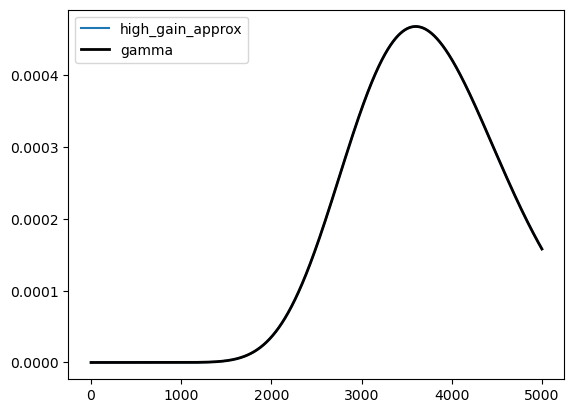

In [17]:
x = np.arange(1, 5_000)
plt.plot(x, amplification_noise(x, n_photons=n_photons, gain=gain), label="high_gain_approx");

alpha = n_photons
beta = 1 / gain
gamma_pdf = stats.gamma.pdf(x, alpha, loc=0, scale=1/beta)
plt.plot(x, gamma_pdf, 'k-', lw=2, label='gamma')

plt.legend();

### High gain approximation probability density function

Combined with a shot-noise controlled emission process this results in the following probability distribution:

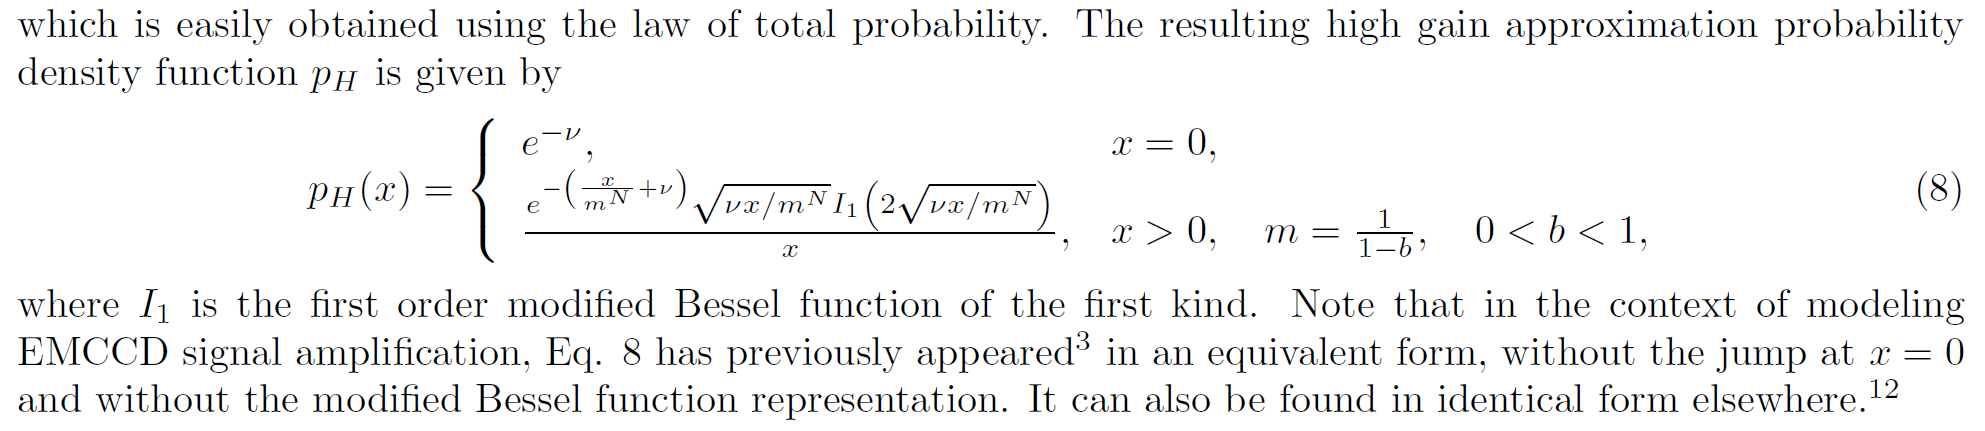

In [18]:
def high_gain_amplification_noise_pmf(x: np.array, lam: int, gain: int) -> np.array:
    x_ = np.atleast_1d(x).astype(float)
    mask = (x_ == 0)
    x_[mask] = np.nan
    result = 1 / x_ * np.exp(-(x_/gain+lam)) * np.sqrt(lam*x_/gain) * iv(1, 2*np.sqrt(lam*x_/gain))
    result[mask] = np.exp(-lam)
    return result

In [19]:
intensity_mean = 1
gain = 200

In [20]:
high_gain_amplification_noise_pmf(x=[0, 1], lam=intensity_mean, gain=gain)

array([0.36787944, 0.0018348 ])

In [21]:
print("mean of amplification_noise:", sum(x*high_gain_amplification_noise_pmf(x, lam=intensity_mean, gain=gain)))

mean of amplification_noise: 199.99982950355613


sum of amplification_noise: 0.9990806813191547


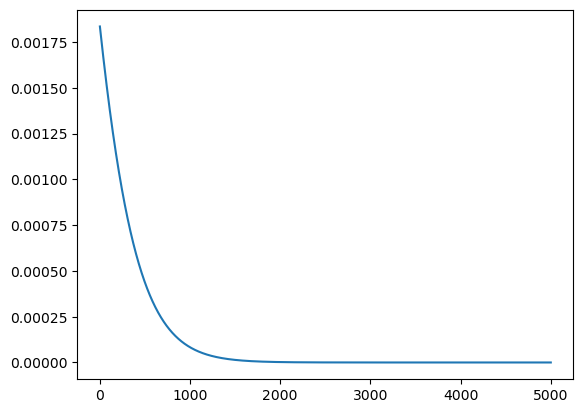

In [22]:
x = np.arange(5_000)
print("sum of amplification_noise:", np.sum(high_gain_amplification_noise_pmf(x, lam=intensity_mean, gain=gain)))
plt.plot(x[x>0], high_gain_amplification_noise_pmf(x[x>0], lam=intensity_mean, gain=gain));

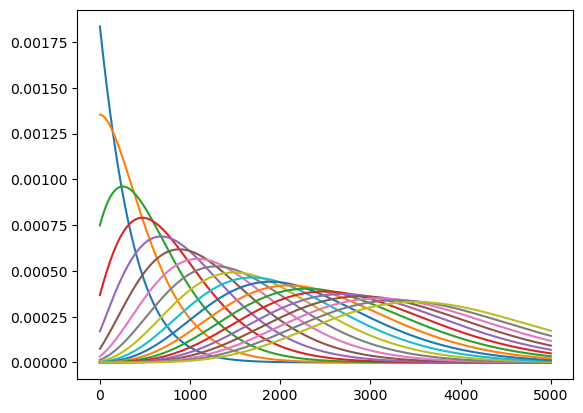

In [23]:
x = np.arange(5_000)
for intensity_mean in range(1, 20):
    plt.plot(x[x>0], high_gain_amplification_noise_pmf(x[x>0], lam=intensity_mean, gain=gain));

[Text(0.5, 1.0, 'high_gain_amplification_noise_pmf(detected_photons=0)'),
 Text(0.5, 0, 'initial photons'),
 Text(0, 0.5, 'pmf')]

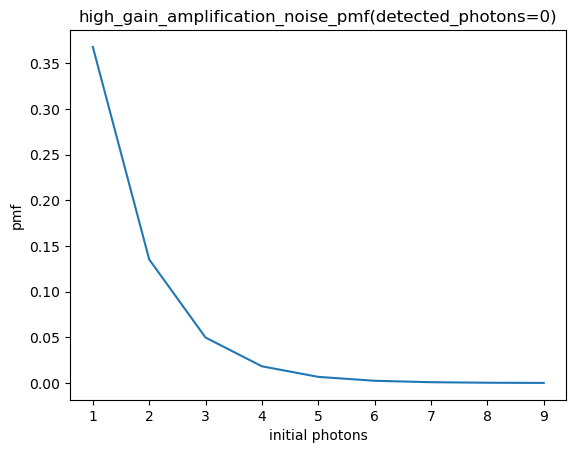

In [24]:
intensity_means = np.arange(1, 10)
y = [high_gain_amplification_noise_pmf(0, lam=intensity_mean, gain=gain) for intensity_mean in intensity_means]
fig, ax = plt.subplots()
ax.plot(intensity_means, y);
ax.set(
    title="high_gain_amplification_noise_pmf(detected_photons=0)",
    xlabel="initial photons",
    ylabel="pmf"
)

#### Fit a gamma distribution

A gamma distribution does not fully describe the high gain amplification noise probability mass function.

Especially when taking the probability for detecting zero photons into account.

In [25]:
intensity_mean = 2
gain = 200

In [26]:
mean = sum(x*high_gain_amplification_noise_pmf(x, lam=intensity_mean, gain=gain))
print("mean of amplification_noise", 
      round(sum(x*high_gain_amplification_noise_pmf(x, lam=intensity_mean, gain=gain))), 
      "is equal to intensity_mean * gain ", 
      intensity_mean*gain)

mean of amplification_noise 400 is equal to intensity_mean * gain  400


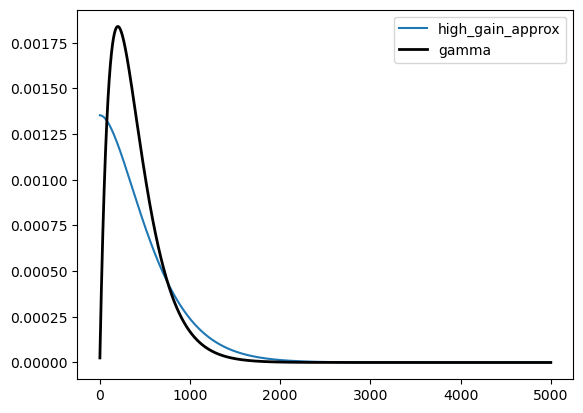

In [27]:
x = np.arange(1, 5_000)
plt.plot(x, high_gain_amplification_noise_pmf(x, lam=intensity_mean, gain=gain), label="high_gain_approx");

alpha = intensity_mean
beta = 1 / gain
gamma_pdf = stats.gamma.pdf(x, alpha, loc=0, scale=1/beta)
plt.plot(x, gamma_pdf, 'k-', lw=2, label='gamma')

plt.legend();

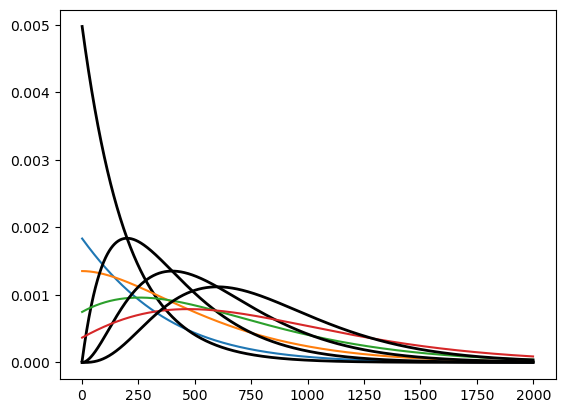

In [28]:
x = np.arange(1, 2_000)
for intensity_mean in range(1, 5):
    plt.plot(x, high_gain_amplification_noise_pmf(x, lam=intensity_mean, gain=gain));
    
    alpha = intensity_mean
    beta = 1 / gain
    gamma_pdf = stats.gamma.pdf(x, alpha, loc=0, scale=1/beta)
    plt.plot(x, gamma_pdf, 'k-', lw=2, label='gamma')

#### Random variable distribution

Deriving a random variable distribution using scipy.stats.rv_discrete is very slow.

In [29]:
def high_gain_amplification_noise_pmf(x: np.array, lam: int, gain: int) -> np.array:
    x_ = np.atleast_1d(x).astype(float)
    mask = (x_ == 0)
    x_[mask] = np.nan
    result = 1 / x_ * np.exp(-(x_/gain+lam)) * np.sqrt(lam*x_/gain) * iv(1, 2*np.sqrt(lam*x_/gain))
    result[mask] = np.exp(-lam)
    return result

In [30]:
%%time
res = high_gain_amplification_noise_pmf(x=np.arange(1000), lam=intensity_mean, gain=gain);

CPU times: total: 0 ns
Wall time: 998 µs


In [31]:
class high_gain_amplification_noise_gen(stats.rv_discrete):

    def _pmf(self, k, lam, gain):

        return high_gain_amplification_noise_pmf(x=k, lam=lam, gain=gain)
    
high_gain_amplification_noise = high_gain_amplification_noise_gen(name="high_gain_amplification_noise", a=0, b=10_000)

In [32]:
intensity_mean = 1
gain = 200
n_samples = 1_000 # more samples are too slow to compute

In [33]:
high_gain_amplification_noise.pmf(k=0, lam=intensity_mean, gain=gain)

0.36787944117144233

In [34]:
high_gain_amplification_noise.pmf(k=1, lam=intensity_mean, gain=gain)

0.0018348025465092053

In [35]:
%%time
intensities = high_gain_amplification_noise.rvs(lam=intensity_mean, gain=gain, size=n_samples, random_state=rng)
intensities.shape

CPU times: total: 4.12 s
Wall time: 4.1 s


(1000,)

In [36]:
intensities.mean()

197.054

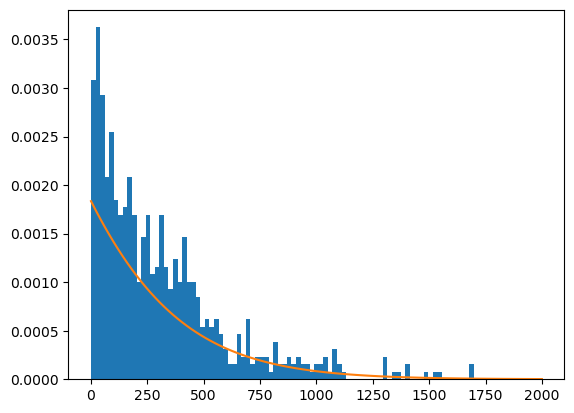

In [37]:
x = np.linspace(1, 2000, 100)
plt.hist(intensities, bins=x, log=False, density=True);
plt.plot(x, high_gain_amplification_noise_pmf(x, lam=intensity_mean, gain=gain));

## Averaging exponential intensity distribution

Each localization is recorded with an intensity of a certain number of photons per recording frame.
Empirically, the intensity in a single frame follows a gamma or exponential distribution.
The mean intensity depends on the integration time which is typically around 10 ms per frame. 
A single fluorophore in dSTORM is typically recorded with a mean on-time of around 10 frames.
The question is, how does the probability distribution for average intensities per on-time look like?

In [38]:
integration_time = 10  # in ms
on_time = 10  # the mean on time in frames
cutoff = 1000
intensity_mean = 2000
n_on_time_intervals = 100_000
n_samples = n_on_time_intervals * on_time * 2

In [39]:
intensities = rng.exponential(scale=intensity_mean-cutoff, size=n_samples) + cutoff
intensities.mean()

2000.0714565076526

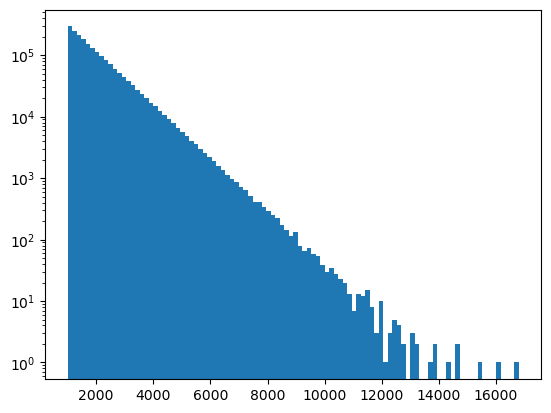

In [40]:
plt.hist(intensities, bins=100, log=True);

In [41]:
on_times = rng.geometric(p=1/on_time, size=n_on_time_intervals)
on_times.mean()

10.0749

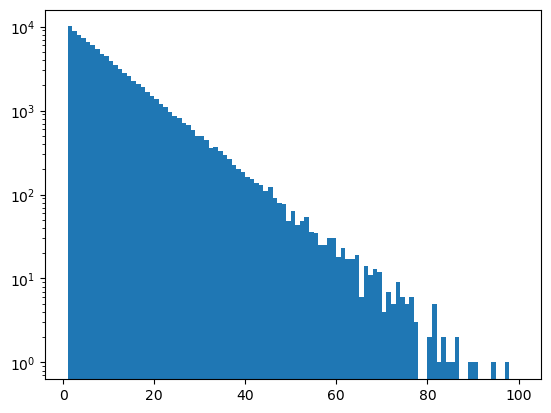

In [42]:
plt.hist(on_times, bins=np.linspace(1, 100, 100), log=True);

In [43]:
mean_intensities = np.array([rng.choice(intensities, size=on_time).mean() for on_time in on_times])
mean_intensities.mean()

1997.8639098429376

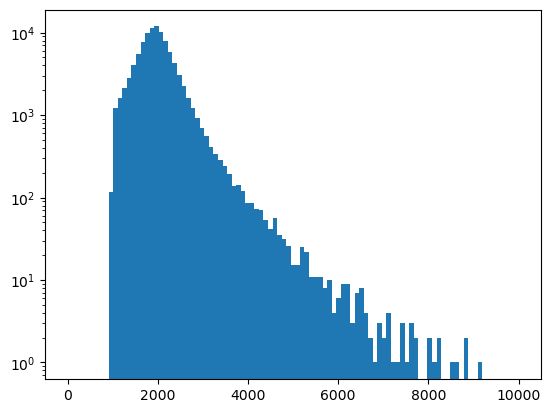

In [44]:
plt.hist(mean_intensities, bins=np.linspace(1, 10_000, 100), log=True);

In [45]:
def compute_mean_intensities(
    on_time,
    intensity_mean,
    n_on_time_intervals,
    n_samples
):
    intensities = rng.exponential(scale=intensity_mean-cutoff, size=n_samples) + cutoff
    on_times = rng.geometric(p=1/on_time, size=n_on_time_intervals)
    mean_intensities = np.array([rng.choice(intensities, size=on_time).mean() for on_time in on_times])
    return mean_intensities

In [46]:
on_time_series = [1, 2, 4, 8, 16]

mean_intensities_series = [compute_mean_intensities(
    on_time_,
    intensity_mean,
    n_on_time_intervals,
    n_samples
)
                          for on_time_ in on_time_series
                          ]

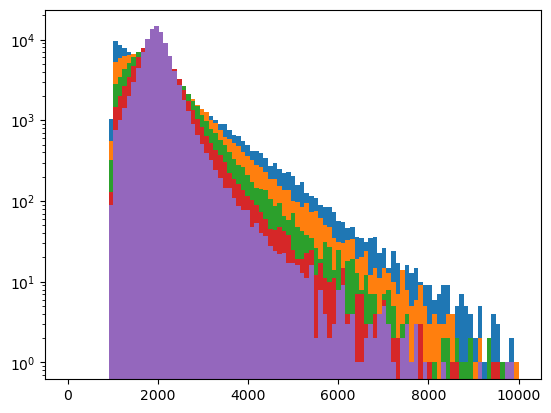

In [47]:
for mean_intensity_ in mean_intensities_series:
    plt.hist(mean_intensity_, bins=np.linspace(1, 10_000, 100), log=True, alpha=1);

Combining all localizations in an on period results in a change of the pdf for the mean intensity with the mean on_time.

The resulting pdf is exponential without averaging and becomes normal for large on_times (strong averaging).

Inbetween the pdf approaches a gamma distribution.

### Fit a gamma distribution

In [48]:
mean_intensity_ = mean_intensities_series[0]
mean_intensity_

array([1576.57396496, 2364.96717917, 2600.45996276, ..., 4427.19817946,
       1686.25096061, 2401.01454285])

In [49]:
fit_alpha, fit_loc, fit_scale = stats.gamma.fit(mean_intensity_, loc=0)
print(fit_alpha, fit_loc, fit_scale)

1.0041012211252562 1000.0059072104475 996.2277465596885


In [50]:
stats.gamma.pdf(1000, a=fit_alpha, loc=fit_loc, scale=fit_scale)

0.0

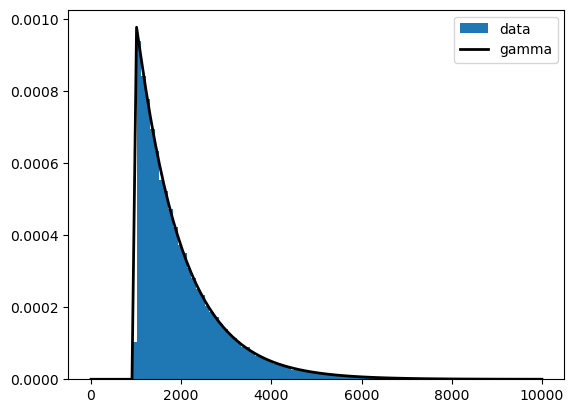

In [51]:
x = np.linspace(1, 10_000, 100)
dist_ = stats.gamma.pdf(x, fit_alpha, loc=fit_loc, scale=fit_scale)
plt.hist(mean_intensity_, bins=x, log=False, density=True, alpha=1, label="data");
plt.plot(x, dist_, 'k-', lw=2, label='gamma')
plt.legend()

In [52]:
fit_parameters = [stats.gamma.fit(mean_intensity_, loc=cutoff) for mean_intensity_ in mean_intensities_series]

Fit parameter: alpha = 1.01, loc= 1e+03, scale=1/beta= 1e+03


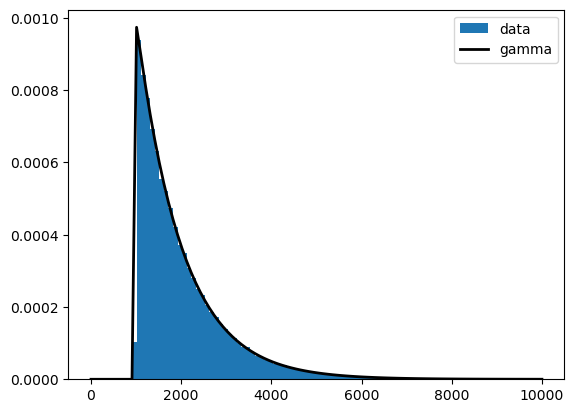

Fit parameter: alpha = 1.48, loc= 9.94e+02, scale=1/beta= 7e+02


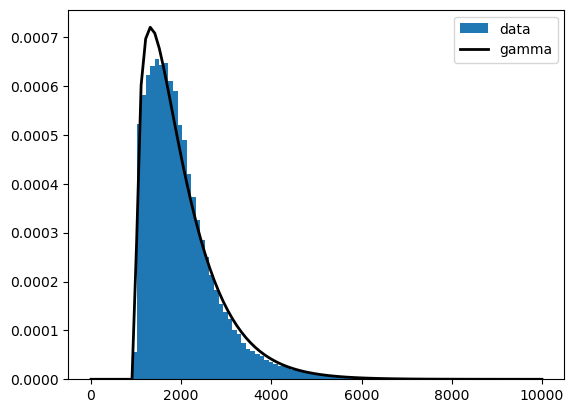

Fit parameter: alpha = 2.81, loc= 9.13e+02, scale=1/beta= 4e+02


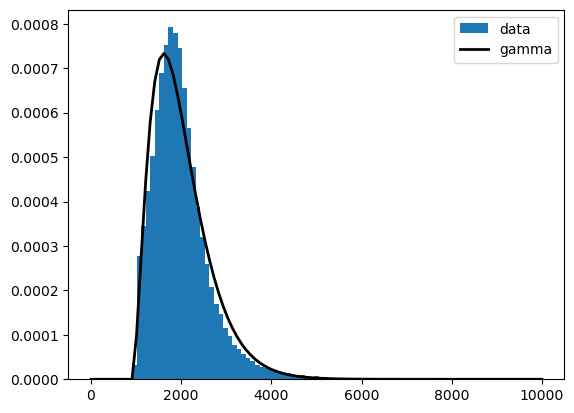

Fit parameter: alpha = 6.05, loc= 7.46e+02, scale=1/beta= 2e+02


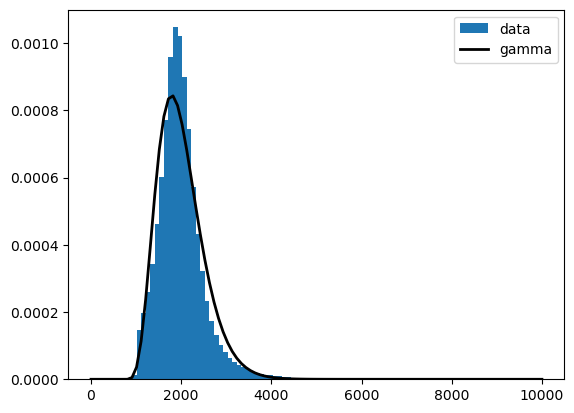

Fit parameter: alpha = 12.4, loc= 5.73e+02, scale=1/beta= 1e+02


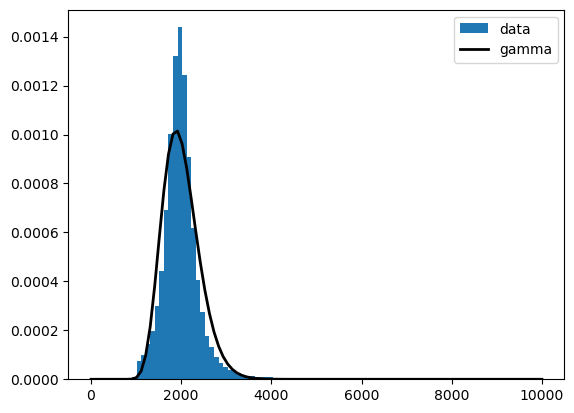

In [53]:
x = np.linspace(1, 10_000, 100)
for mean_intensity_, fit_parameter_ in zip(mean_intensities_series, fit_parameters):
    fit_alpha, fit_loc, fit_scale = fit_parameter_
    print(f"Fit parameter: alpha = {fit_alpha:.3}, loc= {fit_loc:.3}, scale=1/beta= {fit_scale:.0}")
    dist_ = stats.gamma.pdf(x, fit_alpha, loc=fit_loc, scale=fit_scale)
    
    plt.hist(mean_intensity_, bins=x, density=True, log=False, alpha=1, label="data");
    plt.plot(x, dist_, 'k-', lw=2, label='gamma')
    plt.legend()
    plt.show()

#### Same thing on a log scale

Fit parameter: alpha = 1.01, loc= 1e+03, scale=1/beta= 1e+03


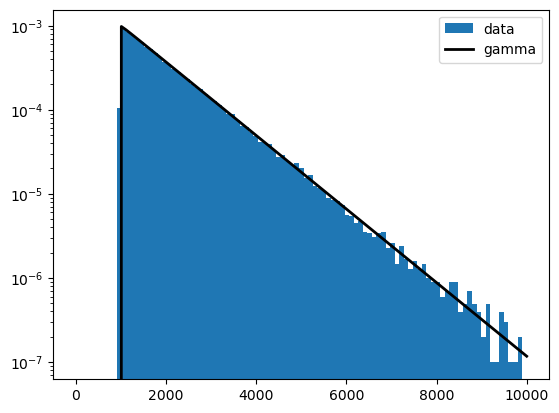

Fit parameter: alpha = 1.48, loc= 9.94e+02, scale=1/beta= 7e+02


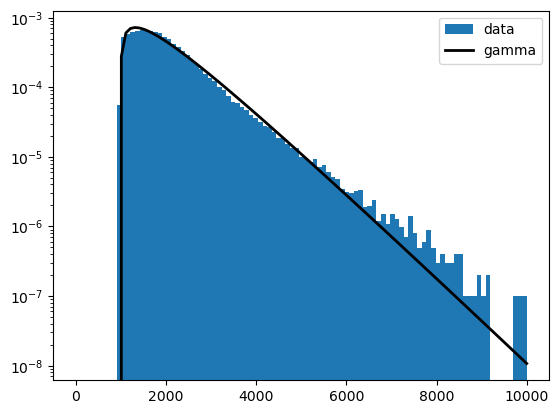

Fit parameter: alpha = 2.81, loc= 9.13e+02, scale=1/beta= 4e+02


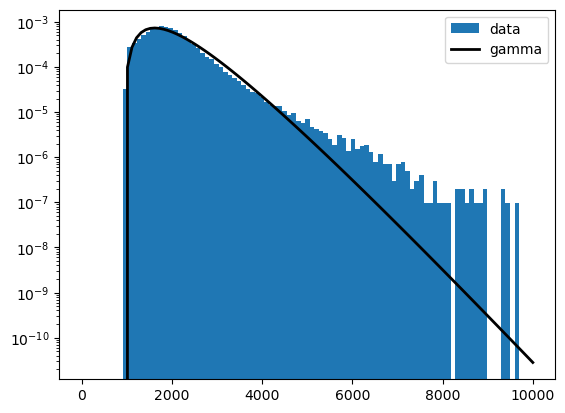

Fit parameter: alpha = 6.05, loc= 7.46e+02, scale=1/beta= 2e+02


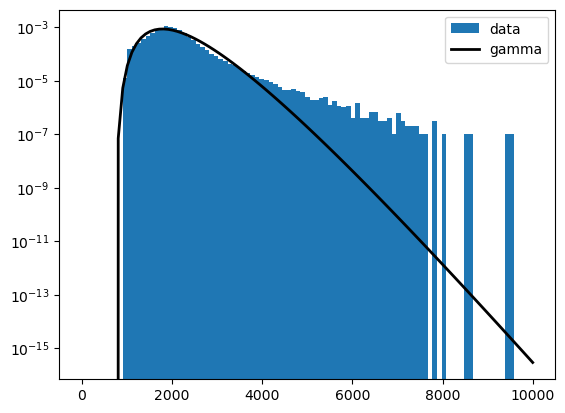

Fit parameter: alpha = 12.4, loc= 5.73e+02, scale=1/beta= 1e+02


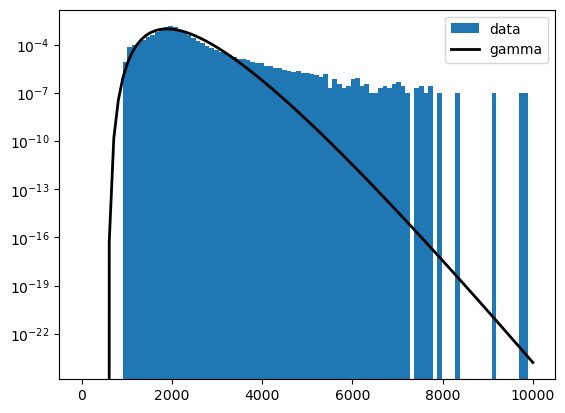

In [54]:
x = np.linspace(1, 10_000, 100)
for mean_intensity_, fit_parameter_ in zip(mean_intensities_series, fit_parameters):
    fit_alpha, fit_loc, fit_scale = fit_parameter_
    print(f"Fit parameter: alpha = {fit_alpha:.3}, loc= {fit_loc:.3}, scale=1/beta= {fit_scale:.0}")
    dist_ = stats.gamma.pdf(x, fit_alpha, loc=fit_loc, scale=fit_scale)
    plt.hist(mean_intensity_, bins=x, density=True, log=True, alpha=1, label="data");
    plt.plot(x, dist_, 'k-', lw=2, label='gamma')
    plt.legend()
    plt.show()